In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pythtb import TBModel, Lattice

## Lien vers les CSV

In [19]:
coords_path = "../files/csv/sirpenski_triangle-equi_points.csv"
edges_path = "../files/csv/sirpenski_triangle-equi_edges.csv"
use_t = False

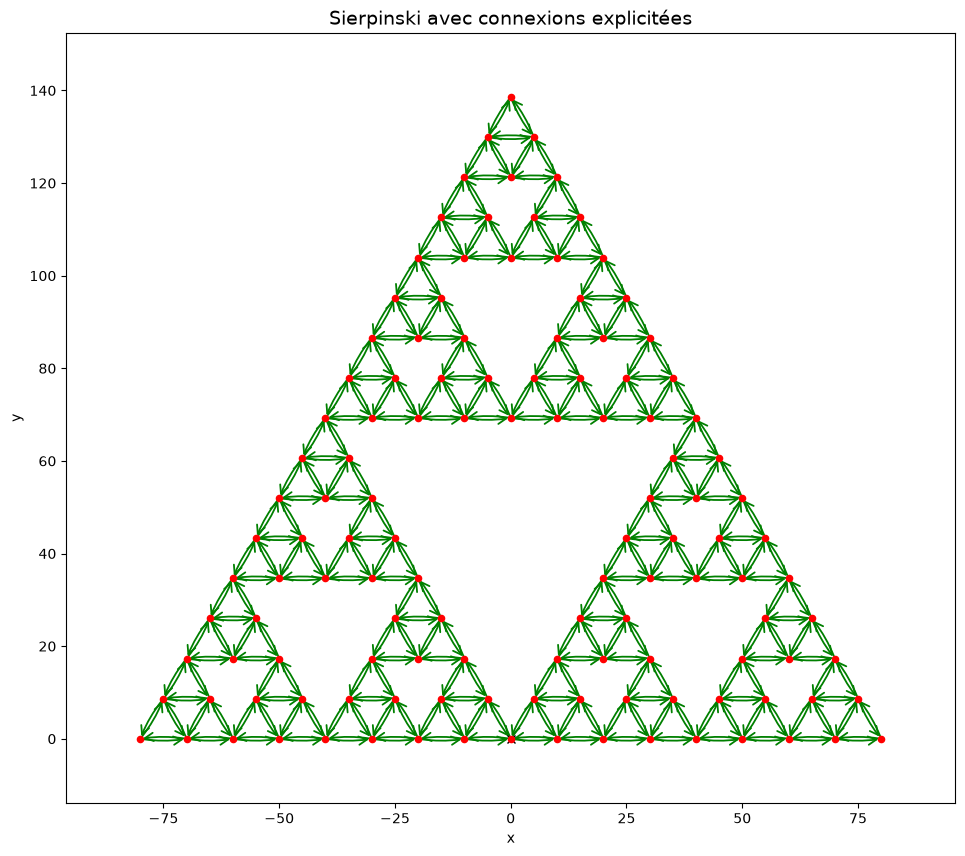

In [24]:
df = pd.read_csv(coords_path, sep=',', decimal='.')
coords = df[['x', 'y']].to_numpy()

df = pd.read_csv(edges_path, sep=',', decimal='.')
if use_t:
    edges = df[['i', 'j', 't']].to_numpy()
else:
    edges = df[['i', 'j']].to_numpy()

# 3. Création du réseau non-périodique
# np.eye(2) = matrice identité de taille 2 => plan orthonormée
lat = Lattice(np.eye(2), coords, periodic_dirs=[])
model = TBModel(lat)

# 4. Paramètres
t_ = -1.0
model.set_onsite([0.0] * len(coords))

# 5. Ajout direct des liaisons depuis le tableau 'edges'
if use_t:
    for i, j, t in edges:
        model.set_hop(t, int(i), int(j)) # attention le cast en int ajoute de l'incertitude
else:
    for i, j in edges:
        model.set_hop(t_, int(i), int(j)) # attention le cast en int ajoute de l'incertitude

# 6. Affichage
fig, ax = model.visualize()
fig.set_size_inches(12, 10)  # Remplacez 12, 10 par les dimensions souhaitées
plt.title("Sierpinski avec connexions explicitées", fontsize=14)
plt.show()

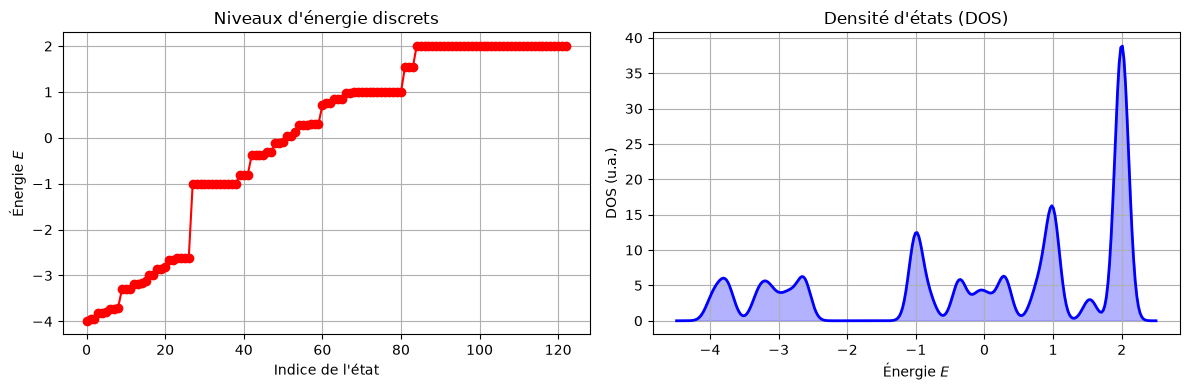

In [25]:
# 1. Calcul des niveaux d'énergie discrets (15 valeurs propres)
evals = model.solve_ham()

# 2. Plot A : Niveaux d'énergie discrets (l'équivalent des "bandes" pour un fractal)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Graphique des valeurs propres
ax1.plot(evals, 'ro-', markersize=6, linewidth=1.5)
ax1.set_title("Niveaux d'énergie discrets")
ax1.set_xlabel("Indice de l'état")
ax1.set_ylabel("Énergie $E$")
ax1.grid(True)

# 3. Plot B : Densité d'états (DOS) lissée
energies = np.linspace(min(evals) - 0.5, max(evals) + 0.5, 300)
sigma = 0.1  # Élargissement gaussien
dos = np.sum([np.exp(-((energies - e) ** 2) / (2 * sigma ** 2)) for e in evals], axis=0)

ax2.plot(energies, dos, 'b-', linewidth=2)
ax2.fill_between(energies, 0, dos, alpha=0.3, color='b')
ax2.set_title("Densité d'états (DOS)")
ax2.set_xlabel("Énergie $E$")
ax2.set_ylabel("DOS (u.a.)")
ax2.grid(True)

plt.tight_layout()
plt.show()